In [1]:
import torch
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate, functional as SF, utils
from torch.utils.data import DataLoader
import tonic
import tonic.transforms as transforms
import tonic.datasets as td
import numpy as np
import numpy.lib.recfunctions as rf
import matplotlib.pyplot as plt
from IPython.display import HTML
import brevitas.nn as qnn

/opt/anaconda3/envs/brevitas_env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_dataset = td.DVSGesture(save_to="./data", train=True)
test_dataset = td.DVSGesture(save_to="./data", train=False)

In [3]:
DVS_GESTURE_CLASSES = [
        "Hand clapping",
        "Right hand wave",
        "Left hand wave",
        "Right arm cw",  # clockwise
        "Right arm ccw",  # counter-clockwise
        "Left arm cw",
        "Left arm ccw",
        "Arm roll",
        "Air drums",
        "Air guitar",
        "Other gestures",
    ]

In [7]:
def to_frames(events):
    frame_transform = tonic.transforms.ToFrame(sensor_size=tonic.datasets.DVSGesture.sensor_size, n_time_bins=120)
    return frame_transform(events)

In [9]:
w,h=32,32
n_frames=32
debug = False

transformer = tonic.transforms.Compose([
    transforms.Denoise(filter_time=10000),
    transforms.Downsample(sensor_size=tonic.datasets.DVSGesture.sensor_size, target_size=(w,h)),
    transforms.ToFrame(sensor_size=(w,h,2), n_time_bins=n_frames),
])

train_trans_data = tonic.datasets.DVSGesture(save_to='./data', transform=transformer, train=True)
test_trans_data = tonic.datasets.DVSGesture(save_to='./data', transform=transformer, train=False)
cached_train = train_trans_data
cached_test = test_trans_data

In [11]:
print(torch.backends.mps.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x = torch.randn(5, 5).to(device)
print(x.device)  # Should print "mps"

True
cpu


In [13]:
grad = surrogate.fast_sigmoid(slope=25)
beta = 0.5
input_dim = 2 * w * h
net = None
optimizer = None
loss_fn = None

In [15]:
grad = snn.surrogate.fast_sigmoid(slope=25) # surrogate.atan()
beta = 0.5

def build_model(dropout_rate):
    return nn.Sequential(
        qnn.QuantConv2d(2, 12, 5, weight_bit_width=8, bias_bit_width=8),
        snn.Leaky(beta=beta, spike_grad=grad, init_hidden=True),

        qnn.QuantConv2d(12, 24, 5, weight_bit_width=8, bias_bit_width=8),
        nn.MaxPool2d(2),
        #nn.Dropout(dropout_rate),
        snn.Leaky(beta=beta, spike_grad=grad, init_hidden=True),

        qnn.QuantConv2d(24, 32, 5, weight_bit_width=8, bias_bit_width=8),
        nn.MaxPool2d(2),
        #nn.Dropout(dropout_rate),
        snn.Leaky(beta=beta, spike_grad=grad, init_hidden=True),

        nn.Flatten(),
        nn.Dropout(dropout_rate),
        qnn.QuantLinear(512, 11, weight_bit_width=8, bias_bit_width=8),
        snn.Leaky(beta=beta, spike_grad=grad, init_hidden=True, output=True)
    ).to(device)

In [17]:
def forward_pass(net, data):
    spk_rec = []
    snn.utils.reset(net) 
    for step in range(data.size(0)):
        spk_out, mem_out = net(data[step])
        spk_rec.append(spk_out)
    return torch.stack(spk_rec)

In [19]:
def validate_model():
    global net
    correct, total = 0, 0
    net.eval()
    with torch.no_grad():
        for batch, (data, targets) in enumerate(test_loader):
            data, targets = data.to(device), targets.to(device)
            spk_rec = forward_pass(net, data)
            correct += SF.accuracy_rate(spk_rec, targets) * data.shape[0]
            total += data.shape[0]
    return correct / total

In [21]:
def plot_acc(tr,ts,ls):
    fig, axes = plt.subplots(1, 3, figsize=(18,4))
    # Plot Train Accuracy
    axes[0].plot(tr)
    axes[0].set_title("Train Set Accuracy")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("Accuracy")

    # Plot Test Accuracy
    axes[1].plot(ts)
    axes[1].set_title("Test Set Accuracy")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Accuracy")
    
    # Plot Training Loss
    axes[2].plot(ls)
    axes[2].set_title("Loss History")
    axes[2].set_xlabel("Iteration")
    axes[2].set_ylabel("Loss")
    
    plt.show()

In [23]:
train_loader = DataLoader(cached_train, batch_size=64, shuffle=True, drop_last=True,
                          collate_fn=tonic.collation.PadTensors(batch_first=False))
test_loader = DataLoader(cached_test, batch_size=32, shuffle=True, drop_last=True,
                         collate_fn=tonic.collation.PadTensors(batch_first=False))

In [25]:
def train_model(epochs):
    global net, optimizer, loss_fn, cnt
    loss_hist = []
    acc_hist = []
    test_acc_hist = []
    for epoch in range(epochs):
        total_loss, total_acc = 0, 0
        ls,tr = 0, 0
        for batch, (data, targets) in enumerate(train_loader):
            data, targets = data.to(device), targets.to(device)

            net.train()
            spk_rec = forward_pass(net, data)
            loss = loss_fn(spk_rec, targets)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_acc += SF.accuracy_rate(spk_rec, targets)
            ls = loss.item()
            loss_hist.append(ls)
            tr = SF.accuracy_rate(spk_rec, targets)
            acc_hist.append(tr)
            print(f"{tr*100:.2f},{ls:.2f}")
        avg_train_loss = total_loss / len(train_loader)
        avg_train_acc = total_acc / len(train_loader)
        test_acc = validate_model()
        test_acc_hist.append(test_acc)
        
        print(f"Epoch {epoch} - Train Loss: {ls:.2f} | Train Acc: {tr*100:.2f}% | Test Acc: {test_acc*100:.2f}%")
        print(f"Avg Train Loss: {avg_train_loss:.2f} | Avg Train Acc: {avg_train_acc*100:.2f}%")

    return acc_hist, test_acc_hist, loss_hist, avg_train_acc, test_acc, avg_train_loss
    

93.75,0.14
89.06,0.69
90.62,0.28
90.62,0.24
90.62,0.20
82.81,0.51
96.88,0.16
87.50,0.27
79.69,0.44
85.94,0.37
84.38,0.46
87.50,0.34
92.19,0.24
95.31,0.15
92.19,0.19
92.19,0.20
Epoch 0 - Train Loss: 0.20 | Train Acc: 92.19% | Test Acc: 82.42%
Avg Train Loss: 0.31 | Avg Train Acc: 89.45%
93.75,0.15
95.31,0.08
85.94,0.39
93.75,0.18
98.44,0.08
95.31,0.14
93.75,0.09
98.44,0.05
95.31,0.22
93.75,0.17
100.00,0.03
96.88,0.08
92.19,0.22
96.88,0.10
89.06,0.32
95.31,0.14
Epoch 1 - Train Loss: 0.14 | Train Acc: 95.31% | Test Acc: 81.25%
Avg Train Loss: 0.15 | Avg Train Acc: 94.63%
96.88,0.07
90.62,0.11
96.88,0.08
92.19,0.20
98.44,0.08
93.75,0.18
93.75,0.17
98.44,0.11
95.31,0.10
96.88,0.09
92.19,0.19
96.88,0.08
100.00,0.03
96.88,0.16
95.31,0.15
95.31,0.11
Epoch 2 - Train Loss: 0.11 | Train Acc: 95.31% | Test Acc: 81.64%
Avg Train Loss: 0.12 | Avg Train Acc: 95.61%
92.19,0.13
96.88,0.12
98.44,0.10
92.19,0.23
96.88,0.11
95.31,0.07
96.88,0.08
90.62,0.23
98.44,0.05
93.75,0.07
98.44,0.07
96.88,0.10
92.19

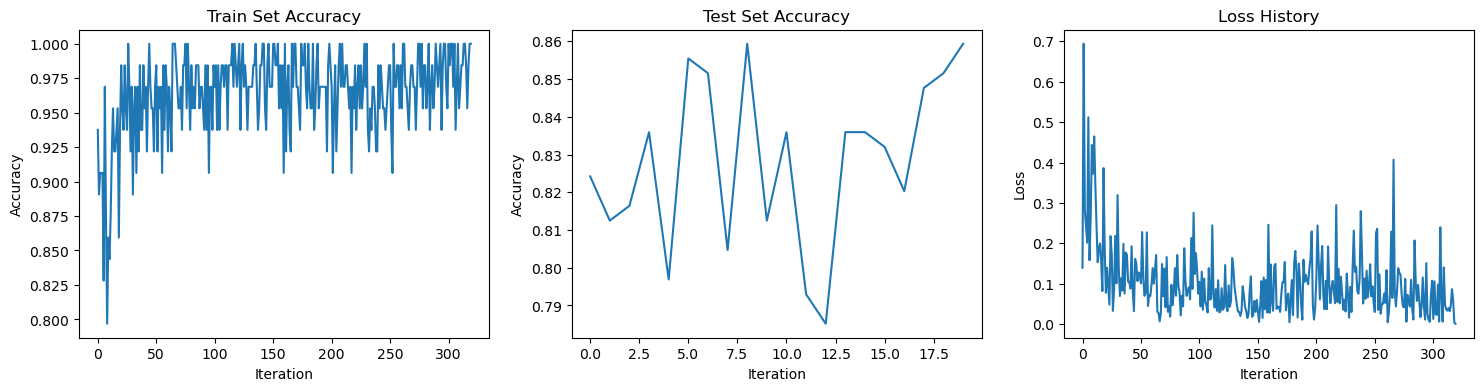

In [83]:
net = build_model(0.2)
float_state_dict = torch.load('nmc_model_state_dict.pth')
net.load_state_dict(float_state_dict, strict=False)
optimizer = torch.optim.Adam(net.parameters(), lr=0.003, betas=(0.9, 0.999))
loss_fn = SF.ce_count_loss()
tr, ts, ls, avtr, avts, avls = train_model(20)
print(f"Plots")
plot_acc(tr, ts, ls)

In [91]:
#torch.save(net, 'nmc_model_full.pth')
torch.save(net.state_dict(), 'nmc_model_state_dict_quantized.pth')

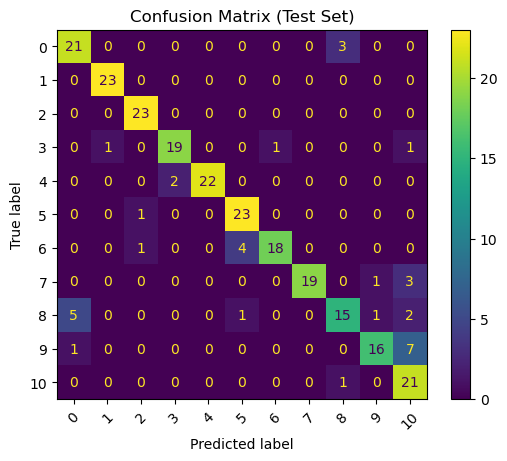

In [93]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds, all_targets = [], []
net.eval()
with torch.no_grad():
    for data, targets in test_loader:
        data, targets = data.to(device), targets.to(device)
        spk_rec = forward_pass(net, data)
        pred = spk_rec.sum(dim=0).argmax(dim=1)
        all_preds.extend(pred.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

cm = confusion_matrix(all_targets, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix (Test Set)")
plt.show()

In [105]:
for i, layer in enumerate(net):
    if isinstance(layer, (qnn.QuantLinear, qnn.QuantConv2d)):
        weight = layer.quant_weight().int()
        np.savetxt(f"layer{i}_weights_quant.csv", weight.flatten(), fmt="%d", delimiter=",")
        
        # Optionally save bias if needed
        if layer.bias is not None:
            bias = layer.bias.detach().cpu().numpy()
            np.savetxt(f"layer{i}_bias_quant.csv", bias.flatten(), fmt="%d", delimiter=",")

In [27]:
from brevitas.export import export_qonnx
import onnx
import onnxruntime as ort
import onnxoptimizer

In [29]:
net = build_model(0.2).to(device)
float_state_dict_quant = torch.load('nmc_model_state_dict_quantized.pth')
net.load_state_dict(float_state_dict_quant, strict=False)

/var/folders/st/s1fxtmt976vg3_pnnmvg9x000000gn/T/ipykernel_11830/1789678531.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  float_state_dict_quant = torch.load('nmc_mode

<All keys matched successfully>

In [31]:
def predict_from_cached_test(index):
    frames, true_label = cached_test[index]  
    frames = torch.from_numpy(frames).float()  
    frames = frames.unsqueeze(1)              
    frames = frames.to(device)
    # Model inference
    net.eval()
    with torch.no_grad():
        spk_rec = forward_pass(net, frames)            
        spike_sum = spk_rec.sum(dim=0)                 
        predicted_class = spike_sum.argmax(dim=1).item()

    predicted_gesture = DVS_GESTURE_CLASSES[predicted_class]
    true_gesture = DVS_GESTURE_CLASSES[true_label]

    # Print results
    print(f"\nIndex: {index}")
    print(f"Predicted Gesture: {predicted_gesture} (Class {predicted_class})")
    print(f"True Gesture: {true_gesture} (Class {true_label})")
    print(f"Prediction Correct? {'Yes' if predicted_class == true_label else 'No'}")

    return predicted_class == true_label
cnter=0
for i in range(20):
    cnter += 1 if predict_from_cached_test(i) else 0
cnter

/opt/anaconda3/envs/brevitas_env/lib/python3.8/site-packages/torch/_tensor.py:1413: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/c10/core/TensorImpl.h:1928.)
  return super().rename(names)
/opt/anaconda3/envs/brevitas_env/lib/python3.8/site-packages/torch/nn/modules/conv.py:454: UserWarning: Defining your `__torch_function__` as a plain method is deprecated and will be an error in future, please define it as a classmethod. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/python_arg_parser.cpp:298.)
  return F.conv2d(input, weight, bias, self.stride,
/opt/anaconda3/envs/brevitas_env/lib/python3.8/site-packages/brevitas/nn/quant_linear.py:69: UserWarning: Defining your `__torch_function__` as a plain method is deprecated and will be an error in


Index: 0
Predicted Gesture: Left arm cw (Class 5)
True Gesture: Left arm cw (Class 5)
Prediction Correct? Yes

Index: 1
Predicted Gesture: Right arm cw (Class 3)
True Gesture: Right arm ccw (Class 4)
Prediction Correct? No

Index: 2
Predicted Gesture: Left arm ccw (Class 6)
True Gesture: Left arm ccw (Class 6)
Prediction Correct? Yes

Index: 3
Predicted Gesture: Arm roll (Class 7)
True Gesture: Arm roll (Class 7)
Prediction Correct? Yes

Index: 4
Predicted Gesture: Right arm cw (Class 3)
True Gesture: Right arm cw (Class 3)
Prediction Correct? Yes

Index: 5
Predicted Gesture: Left hand wave (Class 2)
True Gesture: Left hand wave (Class 2)
Prediction Correct? Yes

Index: 6
Predicted Gesture: Air drums (Class 8)
True Gesture: Hand clapping (Class 0)
Prediction Correct? No

Index: 7
Predicted Gesture: Right hand wave (Class 1)
True Gesture: Right hand wave (Class 1)
Prediction Correct? Yes

Index: 8
Predicted Gesture: Air guitar (Class 9)
True Gesture: Air guitar (Class 9)
Prediction Cor

16